In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. CARGA Y LIMPIEZA DE DATOS
ruta_archivo = r'C:\Users\Usuario\Downloads\Lista de lenguajes de programación 2026.xlsx'
raw_df = pd.read_excel(ruta_archivo)

headers_principales = raw_df.columns
sub_headers = raw_df.iloc[0]

nuevas_columnas = []
categoria_actual = ""

for main, sub in zip(headers_principales, sub_headers):
    if not str(main).startswith("Unnamed"):
        categoria_actual = str(main).strip()

    sub_str = "" if pd.isna(sub) else str(sub).strip()

    if categoria_actual and sub_str:
        nuevas_columnas.append(f"{categoria_actual}_{sub_str}")
    elif categoria_actual:
        nuevas_columnas.append(categoria_actual)
    elif sub_str:
        nuevas_columnas.append(sub_str)
    else:
        nuevas_columnas.append("Alumno")

nuevas_columnas[0] = "Alumno"
nuevas_columnas[-1] = "Observaciones"

df = raw_df.iloc[2:].copy()
df.columns = nuevas_columnas

df["Lenguaje"] = df["Lenguaje"].astype(str).str.strip()
df = df[
    (df["Lenguaje"] != "nan")
    & (df["Lenguaje"] != "")
    & (~df["Lenguaje"].isna())
]

df["AÑO CREAC"] = pd.to_numeric(df["AÑO CREAC"], errors="coerce")

columnas_datos = [
    c
    for c in df.columns
    if c not in ["Alumno", "Lenguaje", "AÑO CREAC", "DISEÑADOR", "Observaciones"]
]

for col in columnas_datos:
    df[col] = df[col].apply(
        lambda x: True
        if str(x).strip() in ["✓", "Si", "SI", "si", "Si ", "SI "]
        else False
    )

df["Década"] = (df["AÑO CREAC"] // 10 * 10).astype("Int64").astype(str) + "s"

print("--- DATASET LIMPIO Y PROCESADO ---")
print(f"Total de lenguajes analizados: {len(df)}")

--- DATASET LIMPIO Y PROCESADO ---
Total de lenguajes analizados: 33


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. CARGA Y LIMPIEZA DE DATOS
ruta_archivo = r'C:\Users\Usuario\Downloads\Lista de lenguajes de programación 2026.xlsx'
raw_df = pd.read_excel(ruta_archivo)

headers_principales = raw_df.columns
sub_headers = raw_df.iloc[0]

nuevas_columnas = []
categoria_actual = ""

for main, sub in zip(headers_principales, sub_headers):
    if not str(main).startswith("Unnamed"):
        categoria_actual = str(main).strip()

    sub_str = "" if pd.isna(sub) else str(sub).strip()

    if categoria_actual and sub_str:
        nuevas_columnas.append(f"{categoria_actual}_{sub_str}")
    elif categoria_actual:
        nuevas_columnas.append(categoria_actual)
    elif sub_str:
        nuevas_columnas.append(sub_str)
    else:
        nuevas_columnas.append("Alumno")

nuevas_columnas[0] = "Alumno"
nuevas_columnas[-1] = "Observaciones"

df = raw_df.iloc[2:].copy()
df.columns = nuevas_columnas

df["Lenguaje"] = df["Lenguaje"].astype(str).str.strip()
df = df[
    (df["Lenguaje"] != "nan")
    & (df["Lenguaje"] != "")
    & (~df["Lenguaje"].isna())
]

df["AÑO CREAC"] = pd.to_numeric(df["AÑO CREAC"], errors="coerce")

columnas_datos = [
    c
    for c in df.columns
    if c not in ["Alumno", "Lenguaje", "AÑO CREAC", "DISEÑADOR", "Observaciones"]
]

for col in columnas_datos:
    df[col] = df[col].apply(
        lambda x: True
        if str(x).strip() in ["✓", "Si", "SI", "si", "Si ", "SI "]
        else False
    )

df["Década"] = (df["AÑO CREAC"] // 10 * 10).astype("Int64").astype(str) + "s"

print("--- DATASET LIMPIO Y PROCESADO ---")
print(f"Total de lenguajes analizados: {len(df)}")

--- DATASET LIMPIO Y PROCESADO ---
Total de lenguajes analizados: 33


In [19]:
# 2. ANÁLISIS Y CONSULTAS
print("--- CANTIDAD DE LENGUAJES POR PARADIGMA ---")
paradigmas = {
    "Imperativo": df["PARADIGMAS_Imperativo"].sum(),
    "Objetos": df["PARADIGMAS_Objetos"].sum(),
    "Funcional": df["PARADIGMAS_Funcional"].sum(),
    "Lógico": df["PARADIGMAS_Logico"].sum(),
}
df_paradigmas = pd.DataFrame(
    list(paradigmas.items()), columns=["Paradigma", "Cantidad"]
)
print(df_paradigmas.to_string(index=False))
print("\n")

print("--- DISTRIBUCIÓN POR DÉCADA ---")
decadas = df["Década"].value_counts().sort_index()
print(decadas.to_string())
print("\n")

print("--- TIPO DE TRADUCTOR ---")
print(f"Compilados: {df['TRADUCTOR_Compilado'].sum()}")
print(f"Interpretados: {df['TRADUCTOR_Interpretado'].sum()}\n")

--- CANTIDAD DE LENGUAJES POR PARADIGMA ---
 Paradigma  Cantidad
Imperativo        26
   Objetos        22
 Funcional        22
    Lógico         0


--- DISTRIBUCIÓN POR DÉCADA ---
Década
1940s    1
1950s    4
1970s    4
1980s    3
1990s    9
2000s    6
2010s    6


--- TIPO DE TRADUCTOR ---
Compilados: 25
Interpretados: 15



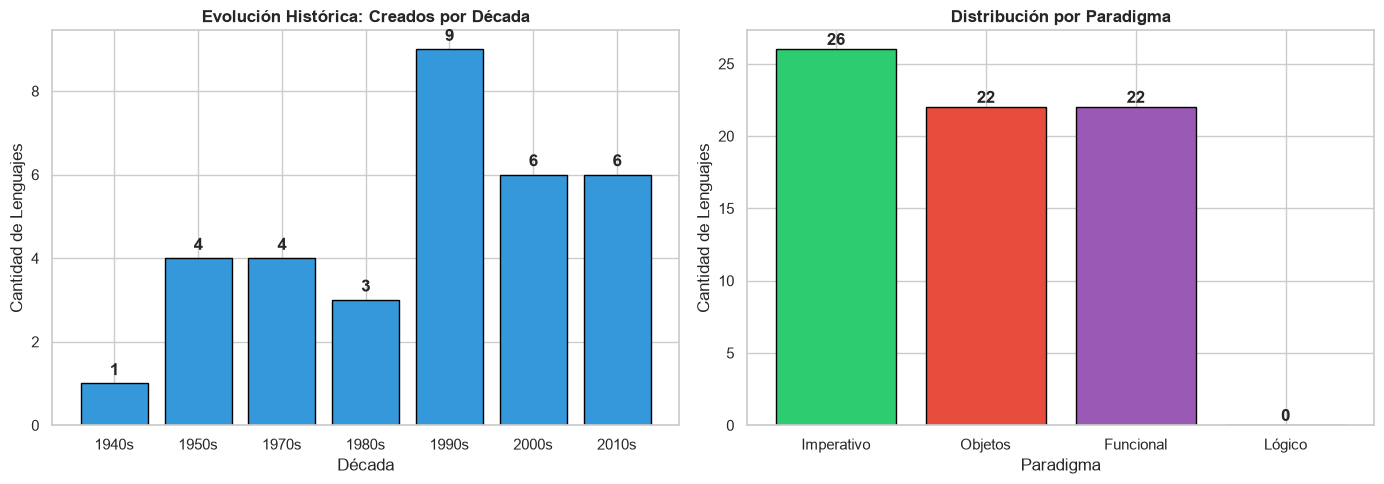

In [20]:
# 3. GENERACIÓN Y GUARDADO DE GRÁFICOS
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(decadas.index, decadas.values, color="#3498db", edgecolor="black")
axes[0].set_title("Evolución Histórica: Creados por Década", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Década")
axes[0].set_ylabel("Cantidad de Lenguajes")

for i, v in enumerate(decadas.values):
    axes[0].text(i, v + 0.2, str(v), ha="center", fontweight="bold")

colores = ["#2ecc71", "#e74c3c", "#9b59b6", "#f1c40f"]
axes[1].bar(
    df_paradigmas["Paradigma"],
    df_paradigmas["Cantidad"],
    color=colores,
    edgecolor="black",
)
axes[1].set_title("Distribución por Paradigma", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Paradigma")
axes[1].set_ylabel("Cantidad de Lenguajes")

for i, v in enumerate(df_paradigmas["Cantidad"]):
    axes[1].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("analisis_lenguajes.png", dpi=300)
plt.show()